# Fase 4: Evaluación end-to-end sobre el conjunto de Test

Entrena con el conjunto de **Training Data** (o el subconjunto que ya venías usando) y evalúa sobre **Test Data** de ISIC 2016 — el modelo nunca ve estas imágenes durante entrenamiento. Reconstruye la máscara predicha por imagen, la compara contra el ground-truth real con IoU/Dice/precisión/recall, y muestra los resultados visual y numéricamente.

### Setup

In [1]:
import sys; sys.path.append('..')

from src.io_utils import cargar_imagen, cargar_mascara, listar_pares_imagen_mascara
from src.presegmentation import presegmentar_superpixeles
from src.quaternion_qft import procesar_qft_superpixeles
from src.feature_extraction import extraer_matriz_caracteristicas, normalizar_caracteristicas
from src.classification import etiquetar_superpixeles, entrenar_modelo, predecir
from src.evaluation import reconstruir_mascara, calcular_metricas

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

N_SEGMENTOS = 100
UMBRAL_ETIQUETADO = 0.5


TIPO_MODELO = "random_forest"   # cambia según lo que decidieron con fase3

pares_train = listar_pares_imagen_mascara('../data/raw/train', '../data/masks/train')
pares_test = listar_pares_imagen_mascara('../data/raw/test', '../data/masks/test')

print("Imágenes de entrenamiento disponibles:", len(pares_train))
print("Imágenes de test disponibles:", len(pares_test))

Imágenes de entrenamiento disponibles: 900
Imágenes de test disponibles: 379


## 1. Entrenar el modelo final

Usa un subconjunto de train (ajusta `N_TRAIN`) — sube el número una vez que confirmes que corre bien.

In [2]:
N_TRAIN = 40  # cámbialo a len(pares_train) para usar todo el training set

def construir_dataset(pares, n_segmentos, umbral):
    """Corre el pipeline de features+etiquetado sobre una lista de pares (imagen, mascara)."""
    X_acum, y_acum, fallidas = [], [], []
    for ruta_img, ruta_mask in pares:
        try:
            img = cargar_imagen(ruta_img)
            mask = cargar_mascara(ruta_mask)
            regiones = presegmentar_superpixeles(img, n_segmentos=n_segmentos)
            espectros = procesar_qft_superpixeles(img, regiones)
            X_img = extraer_matriz_caracteristicas(espectros)
            y_img = etiquetar_superpixeles(regiones, mask, umbral=umbral)
            X_acum.append(X_img)
            y_acum.append(y_img)
        except Exception as e:
            fallidas.append((ruta_img, str(e)))
    if fallidas:
        print(f"⚠️  {len(fallidas)} imágenes fallaron durante construcción del dataset:")
        for ruta, err in fallidas:
            print(f"   {ruta}: {err}")
    return np.vstack(X_acum), np.concatenate(y_acum)

X_train, y_train = construir_dataset(pares_train[:N_TRAIN], N_SEGMENTOS, UMBRAL_ETIQUETADO)
X_train_norm = normalizar_caracteristicas(X_train, metodo='zscore')

modelo = entrenar_modelo(X_train_norm, y_train, tipo_modelo=TIPO_MODELO)
print(f"Modelo '{TIPO_MODELO}' entrenado con {X_train.shape[0]} superpíxeles de {N_TRAIN} imágenes.")

Modelo 'random_forest' entrenado con 4312 superpíxeles de 40 imágenes.


## 2. Evaluar sobre el conjunto de Test, imagen por imagen

Para cada imagen de test: presegmenta, calcula QFT y características, predice por superpíxel, reconstruye la máscara completa, y compara contra el ground-truth real.

In [3]:
N_TEST = 15  # cámbialo a len(pares_test) para evaluar sobre todo el test set

resultados_por_imagen = []

for i, (ruta_img, ruta_mask) in enumerate(pares_test[:N_TEST]):
    try:
        img = cargar_imagen(ruta_img)
        mask_real = cargar_mascara(ruta_mask)

        regiones = presegmentar_superpixeles(img, n_segmentos=N_SEGMENTOS)
        espectros = procesar_qft_superpixeles(img, regiones)
        X_img = extraer_matriz_caracteristicas(espectros)
        X_img_norm = normalizar_caracteristicas(X_img, metodo='zscore')

        y_pred = predecir(modelo, X_img_norm)
        mask_pred = reconstruir_mascara(regiones, y_pred, forma=img.shape[:2])

        metricas = calcular_metricas(mask_pred, mask_real)
        metricas["imagen"] = ruta_img.split('/')[-1]
        resultados_por_imagen.append(metricas)

    except Exception as e:
        print(f"⚠️  Falló {ruta_img}: {e}")

    if (i + 1) % 5 == 0 or (i + 1) == N_TEST:
        print(f"  {i + 1}/{N_TEST} imágenes de test evaluadas")

df_resultados = pd.DataFrame(resultados_por_imagen)
df_resultados = df_resultados[["imagen", "iou", "dice", "precision", "recall"]]
df_resultados

  5/15 imágenes de test evaluadas
  10/15 imágenes de test evaluadas
  15/15 imágenes de test evaluadas


,imagen,iou,dice,precision,recall
0,ISIC_0000003.jpg,0.654635,0.791274,0.757000,0.828800
1,ISIC_0000012.jpg,0.100218,0.182178,0.122877,0.352108
2,ISIC_0000013.jpg,0.387878,0.558952,0.572974,0.545599
3,ISIC_0000014.jpg,0.607483,0.755819,0.825933,0.696677
4,ISIC_0000015.jpg,0.522594,0.686453,0.708954,0.665336
5,ISIC_0000020.jpg,0.651470,0.788958,0.857798,0.730346
6,ISIC_0000022.jpg,0.553052,0.712213,0.949262,0.569899
7,ISIC_0000023.jpg,0.659675,0.794945,0.732681,0.868775
8,ISIC_0000027.jpg,0.526898,0.690154,0.679148,0.701523
9,ISIC_0000036.jpg,0.539909,0.701222,0.840707,0.601435


### Métricas promedio sobre el conjunto de test

In [4]:
resumen = df_resultados[["iou", "dice", "precision", "recall"]].agg(["mean", "std", "min", "max"])
resumen

,iou,dice,precision,recall
mean,0.526136,0.673565,0.733002,0.662013
std,0.160239,0.164519,0.239404,0.142929
min,0.100218,0.182178,0.122877,0.352108
max,0.722396,0.838827,0.997086,0.883432


### Distribución de IoU y Dice por imagen

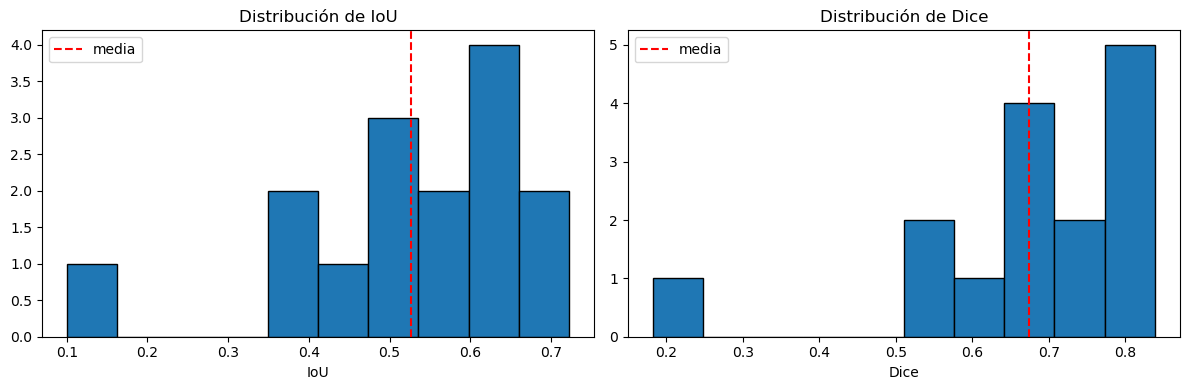

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_resultados["iou"], bins=10, edgecolor="black")
axes[0].axvline(df_resultados["iou"].mean(), color="red", linestyle="--", label="media")
axes[0].set_title("Distribución de IoU")
axes[0].set_xlabel("IoU"); axes[0].legend()

axes[1].hist(df_resultados["dice"], bins=10, edgecolor="black")
axes[1].axvline(df_resultados["dice"].mean(), color="red", linestyle="--", label="media")
axes[1].set_title("Distribución de Dice")
axes[1].set_xlabel("Dice"); axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Visualización lado a lado

Mira el mejor y el peor caso según IoU — ayuda a entender en qué tipo de imágenes falla el modelo (ej. lesiones muy irregulares, bajo contraste, pelo/vello cubriendo la piel).

=== Mejor caso ===


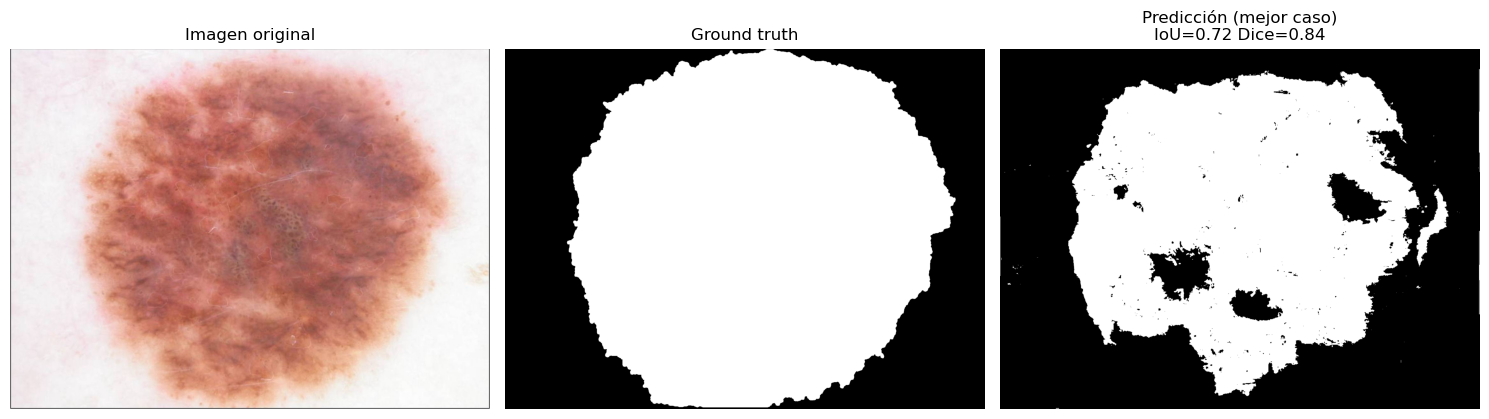

=== Peor caso ===


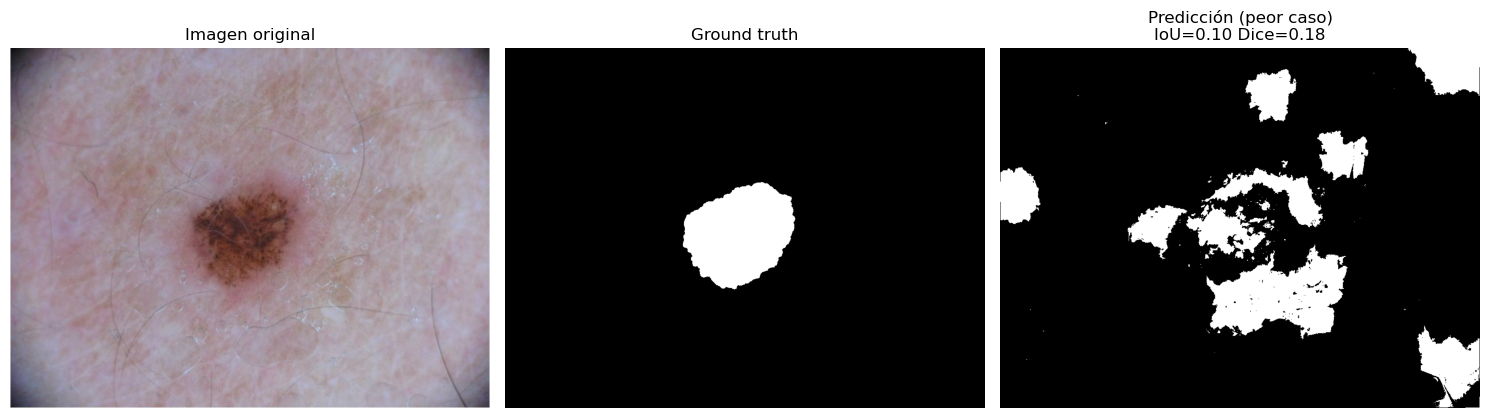

{'iou': 0.10021771872529411,
 'dice': 0.1821779762671079,
 'precision': 0.1228767849633296,
 'recall': 0.3521075105440096}

In [6]:
def visualizar_resultado(ruta_img, ruta_mask, modelo, n_segmentos, titulo_extra=""):
    img = cargar_imagen(ruta_img)
    mask_real = cargar_mascara(ruta_mask)

    regiones = presegmentar_superpixeles(img, n_segmentos=n_segmentos)
    espectros = procesar_qft_superpixeles(img, regiones)
    X_img = normalizar_caracteristicas(extraer_matriz_caracteristicas(espectros), metodo='zscore')
    y_pred = predecir(modelo, X_img)
    mask_pred = reconstruir_mascara(regiones, y_pred, forma=img.shape[:2])

    metricas = calcular_metricas(mask_pred, mask_real)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img); axes[0].set_title("Imagen original"); axes[0].axis("off")
    axes[1].imshow(mask_real, cmap="gray"); axes[1].set_title("Ground truth"); axes[1].axis("off")
    axes[2].imshow(mask_pred, cmap="gray")
    axes[2].set_title(f"Predicción {titulo_extra}\nIoU={metricas['iou']:.2f} Dice={metricas['dice']:.2f}")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()
    return metricas

idx_mejor = df_resultados["iou"].idxmax()
idx_peor = df_resultados["iou"].idxmin()

ruta_mejor = pares_test[idx_mejor]
ruta_peor = pares_test[idx_peor]

print("=== Mejor caso ===")
visualizar_resultado(*ruta_mejor, modelo, N_SEGMENTOS, titulo_extra="(mejor caso)")

print("=== Peor caso ===")
visualizar_resultado(*ruta_peor, modelo, N_SEGMENTOS, titulo_extra="(peor caso)")

## Siguiente paso

`df_resultados` y `resumen` ya tienen las tablas listas para pegar en la sección de Experimentación del reporte. Las figuras del mejor/peor caso sirven para la discusión cualitativa de resultados (qué tipo de imágenes son más difíciles para el modelo).